In [114]:
%reload_ext autoreload
%autoreload 2

from fista import LogisticLassoFistaCV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score

import numpy as np

In [145]:
def generate_high_dim_data(n: int, p: int):
    assert p > 5

    X = np.random.normal(0, 1, size=(n, p))

    beta_true = np.zeros(p)
    true_weights = np.array([2.5, -2.0, 1.5, -1.0, 3.0])
    n_informative = len(true_weights)

    beta_true[:n_informative] = true_weights[:n_informative]

    z = 0.5 + X @ beta_true
    prob = 1 / (1 + np.exp(-z))
    y = np.random.binomial(1, prob)

    return X, y, beta_true

In [146]:
def perform_repeated_holdout(X, y, lambdas, measure: str, n_splits: int, test_size: float=0.3):
    llf = LogisticLassoFistaCV(lambdas)

    for i in range(n_splits):
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=i)
    
        llf.fit(X_train, y_train, max_iter=50, warm_start=True)
        llf.validate(X_val, y_val, measure)
        
        print(f"Finished split [{i+1}/{n_splits}]")
    
    llf.plot(measure)
    llf.plot_coefficients()

    return llf

Finished split [1/10]
Finished split [2/10]
Finished split [3/10]
Finished split [4/10]
Finished split [5/10]
Finished split [6/10]
Finished split [7/10]
Finished split [8/10]
Finished split [9/10]
Finished split [10/10]


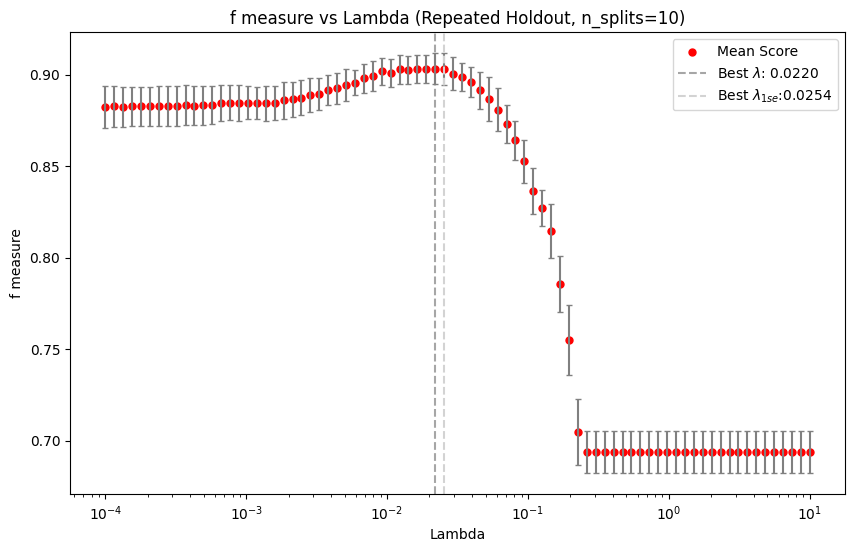

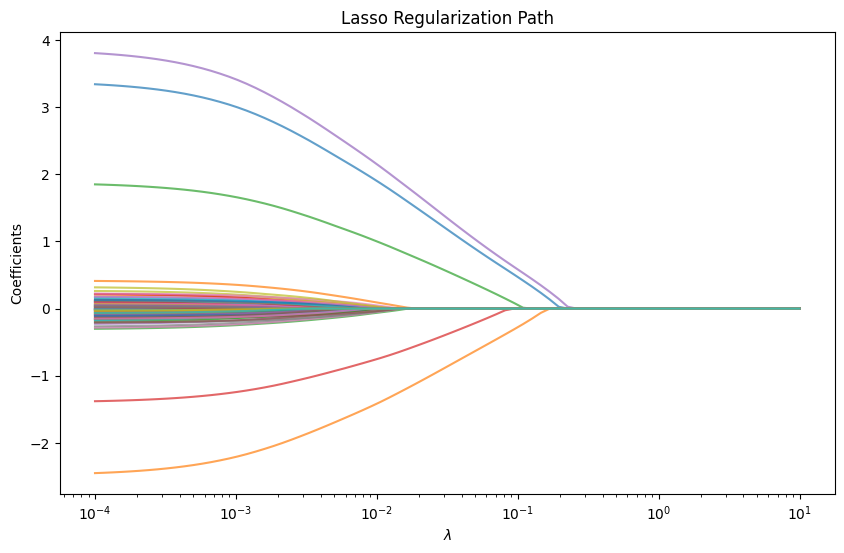

In [154]:
X, y, beta_true = generate_high_dim_data(n=2000, p=100)
    
n_splits = 10
test_size = 0.3
measure = "f"
lambdas = np.logspace(-4, 1, 80)

llf = perform_repeated_holdout(X, y, lambdas, measure, n_splits, test_size)